# Trilha A — Treino Final e Avaliação no Teste

Treina os melhores modelos selecionados na Tarefa 5 (trilha_a.ipynb) usando o conjunto trainval completo,
dividido internamente em treino e validação, e avalia no conjunto de teste fixo definido no CSV (`split`).

**Pipeline de cada modelo:**
- Treino/teste vêm da coluna `split` do CSV (`trainval` / `test`) — sem re-split de teste
- Split interno do trainval → treino (80%) + validação (20%) estratificado
- `StandardScaler → SelectKBest (F-Score ANOVA) → Classificador`
- Ajuste do threshold via Youden's J na validação
- Avaliação final no conjunto de teste do CSV com threshold=0.5 e threshold de Youden

## Env Configuration

Importacoes, caminhos, parametros globais e carregamento da selecao de modelos (task5_top_models.csv) da Trilha A.

In [ ]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data', 'images', 'datasets')
MODULES_DIR  = os.path.join(PROJECT_ROOT, 'modules')
INPUT_DIR    = os.path.join(PROJECT_ROOT, 'experiments', 'trilha_a')
OUTPUT_DIR   = os.path.join(PROJECT_ROOT, 'experiments', 'trilha_a_final')

if MODULES_DIR not in sys.path:
    sys.path.insert(0, MODULES_DIR)

from models import ALL_CLASSIFIERS, build_selectkbest_pipeline
from evaluation import (
    META_COLS, DATASETS, compute_metrics,
    youden_threshold, evaluate_at_threshold, get_scores,
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

K_FEATURES = 20
VAL_SIZE   = 0.20
SEED       = 42

# --- Estilo Seaborn + paleta pastel (azul, turquesa, roxo) ---
sns.set_theme(style='whitegrid', font_scale=1.0, rc={
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.alpha': 0.3,
    'font.family': 'sans-serif',
})

PASTEL_COLORS = {
    'BW':         '#A3C4F3',
    'Doppler':    '#80CED7',
    'BW+Doppler': '#C3AED6',
}
ACCENT_COLORS = {
    'BW':         '#5B8DB8',
    'Doppler':    '#4A9EA6',
    'BW+Doppler': '#8B6FB0',
}
DS_COLORS = PASTEL_COLORS

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'INPUT_DIR    : {INPUT_DIR}')
print(f'OUTPUT_DIR   : {OUTPUT_DIR}')
print(f'K_FEATURES   : {K_FEATURES}')

## Functions

`youden_threshold`, `evaluate_at_threshold` e `get_scores` vêm de `modules/evaluation.py`.

## Process

Pipeline completo do treino final da Trilha A:
1. Le a selecao de modelos do kfold (task5_top_models.csv)
2. Para cada dataset: separa trainval e teste pela coluna `split` do CSV
3. Divide apenas o trainval em treino/validacao (80/20 estratificado)
4. Treina o melhor modelo no trainval completo (StandardScaler -> SelectKBest -> clf)
5. Calcula threshold de Youden na validacao
6. Avalia no conjunto de teste do CSV com threshold=0.5 e threshold de Youden
7. Salva resultados e visualizacoes

### 1. Carregamento da selecao de modelos e datasets

In [17]:
df_top  = pd.read_csv(os.path.join(INPUT_DIR, 'task5_top_models.csv'))
clf_map = dict(ALL_CLASSIFIERS)

dfs = {}
for ds_name, ds_file in DATASETS.items():
    df = pd.read_csv(os.path.join(DATA_DIR, ds_file))
    dfs[ds_name] = df
    feat_cols = [c for c in df.columns if c not in META_COLS]
    trainval  = df[df['split'] == 'trainval']
    test      = df[df['split'] == 'test']
    row = df_top[df_top['dataset'] == ds_name].iloc[0]
    print(f'=== {ds_name} ===')
    print(f'  trainval: {len(trainval)} | test: {len(test)} | features: {len(feat_cols)}')
    print(f'  Melhor modelo (kfold): {row["model"]}  (AUC kfold={row["auc_mean"]:.3f})')
    print()

print(f'Modelos selecionados: {len(df_top)}')


=== BW ===
  trainval: 178 | test: 20 | features: 465
  Melhor modelo (kfold): Coarse Gaussian SVM  (AUC kfold=0.779)

=== Doppler ===
  trainval: 178 | test: 20 | features: 465
  Melhor modelo (kfold): Subspace Discriminant  (AUC kfold=0.825)

=== BW+Doppler ===
  trainval: 178 | test: 20 | features: 930
  Melhor modelo (kfold): Subspace Discriminant  (AUC kfold=0.808)

Modelos selecionados: 3


### 2. Divisão trainval → treino + validação (teste vem do CSV)

In [18]:
splits = {}
for ds_name, df in dfs.items():
    feat_cols = [c for c in df.columns if c not in META_COLS]

    # Treino/teste fixos definidos no CSV — não re-splitar o teste
    trainval = df[df['split'] == 'trainval']
    test     = df[df['split'] == 'test']

    X_tv = trainval[feat_cols].values.astype(float)
    y_tv = trainval['target'].values
    X_te = test[feat_cols].values.astype(float)
    y_te = test['target'].values

    # Split interno apenas do trainval para calibrar threshold (Youden)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tv, y_tv,
        test_size=VAL_SIZE,
        stratify=y_tv,
        random_state=SEED,
    )

    splits[ds_name] = {
        'X_train': X_tr, 'y_train': y_tr,
        'X_val':   X_val, 'y_val':   y_val,
        'X_test':  X_te,  'y_test':  y_te,
        'feat_cols': feat_cols,
    }

    print(f'{ds_name}: treino={len(y_tr)} | val={len(y_val)} | teste={len(y_te)}')
    print(f'  treino  — Benigno={int((y_tr==0).sum())} | Maligno={int((y_tr==1).sum())}')
    print(f'  val     — Benigno={int((y_val==0).sum())} | Maligno={int((y_val==1).sum())}')
    print(f'  teste   — Benigno={int((y_te==0).sum())} | Maligno={int((y_te==1).sum())}')
    print()

BW: treino=142 | val=36 | teste=20
  treino  — Benigno=94 | Maligno=48
  val     — Benigno=24 | Maligno=12
  teste   — Benigno=13 | Maligno=7

Doppler: treino=142 | val=36 | teste=20
  treino  — Benigno=94 | Maligno=48
  val     — Benigno=24 | Maligno=12
  teste   — Benigno=13 | Maligno=7

BW+Doppler: treino=142 | val=36 | teste=20
  treino  — Benigno=94 | Maligno=48
  val     — Benigno=24 | Maligno=12
  teste   — Benigno=13 | Maligno=7



### 3. Treino final no trainval completo e avaliacao no teste

In [ ]:
results = []
trained_pipes = {}
test_probs = {}
test_is_proba = {}

for ds_name in DATASETS:
    sp         = splits[ds_name]
    X_tv       = np.vstack([sp['X_train'], sp['X_val']])
    y_tv       = np.concatenate([sp['y_train'], sp['y_val']])
    X_val      = sp['X_val']
    y_val      = sp['y_val']
    X_te       = sp['X_test']
    y_te       = sp['y_test']

    row_top    = df_top[df_top['dataset'] == ds_name].iloc[0]
    model_name = row_top['model']

    if model_name not in clf_map:
        print(f'[SKIP] {model_name} nao encontrado em ALL_CLASSIFIERS')
        continue

    k_eff = min(K_FEATURES, X_tv.shape[1])
    pipe  = build_selectkbest_pipeline(clone(clf_map[model_name]), k_eff)
    pipe.fit(X_tv, y_tv)
    trained_pipes[ds_name] = pipe

    try:
        prob_val, is_proba = get_scores(pipe, X_val)
        prob_test, _       = get_scores(pipe, X_te)
        test_probs[ds_name]    = prob_test
        test_is_proba[ds_name] = is_proba

        thr_youden  = youden_threshold(y_val, prob_val)
        val_05      = evaluate_at_threshold(y_val, prob_val, 0.5)
        val_youden  = evaluate_at_threshold(y_val, prob_val, thr_youden)
        test_05     = evaluate_at_threshold(y_te, prob_test, 0.5)
        test_youden = evaluate_at_threshold(y_te, prob_test, thr_youden)

        row = {
            'dataset':            ds_name,
            'model':              model_name,
            'k_features':         k_eff,
            'threshold_youden':   thr_youden,
            'val_auc_05':         val_05['auc'],
            'val_acc_05':         val_05['accuracy'],
            'val_sens_05':        val_05['sensitivity'],
            'val_spec_05':        val_05['specificity'],
            'val_f1_05':          val_05['f1'],
            'val_auc_youden':     val_youden['auc'],
            'val_acc_youden':     val_youden['accuracy'],
            'val_sens_youden':    val_youden['sensitivity'],
            'val_spec_youden':    val_youden['specificity'],
            'val_f1_youden':      val_youden['f1'],
            'test_auc_05':        test_05['auc'],
            'test_acc_05':        test_05['accuracy'],
            'test_sens_05':       test_05['sensitivity'],
            'test_spec_05':       test_05['specificity'],
            'test_f1_05':         test_05['f1'],
            'test_tn_05':         test_05['tn'],
            'test_fp_05':         test_05['fp'],
            'test_fn_05':         test_05['fn'],
            'test_tp_05':         test_05['tp'],
            'test_auc_youden':    test_youden['auc'],
            'test_acc_youden':    test_youden['accuracy'],
            'test_sens_youden':   test_youden['sensitivity'],
            'test_spec_youden':   test_youden['specificity'],
            'test_f1_youden':     test_youden['f1'],
            'test_tn_youden':     test_youden['tn'],
            'test_fp_youden':     test_youden['fp'],
            'test_fn_youden':     test_youden['fn'],
            'test_tp_youden':     test_youden['tp'],
        }
        results.append(row)

        print(f'{ds_name} | {model_name}  [K={k_eff}]')
        print(f'  threshold Youden={thr_youden:.3f}')
        print(f'  val   AUC={val_05["auc"]:.3f}  Acc={val_05["accuracy"]:.3f}')
        print(f'  teste AUC={test_05["auc"]:.3f}  Acc={test_05["accuracy"]:.3f}  '
              f'Sens={test_05["sensitivity"]:.3f}  Spec={test_05["specificity"]:.3f}')
        print(f'  teste (Youden) AUC={test_youden["auc"]:.3f}  Acc={test_youden["accuracy"]:.3f}  '
              f'Sens={test_youden["sensitivity"]:.3f}  Spec={test_youden["specificity"]:.3f}')
        print()

    except Exception as e:
        print(f'[ERRO] {ds_name} | {model_name}: {e}')
        print()

df_results = pd.DataFrame(results)
print(f'Total: {len(df_results)} modelos avaliados no teste')


### 4. Salvar resultados

In [20]:
out_csv = os.path.join(OUTPUT_DIR, 'test_results.csv')
df_results.to_csv(out_csv, index=False)
print(f'Resultados salvos → {out_csv}  ({len(df_results)} linhas)\n')

display(
    df_results[['dataset', 'model', 'test_auc_05', 'test_acc_05',
                'test_sens_05', 'test_spec_05', 'test_f1_05',
                'test_auc_youden', 'test_sens_youden', 'test_spec_youden']]
    .sort_values(['dataset', 'test_auc_05'], ascending=[True, False])
    .reset_index(drop=True)
    .style.format({
        c: '{:.3f}' for c in ['test_auc_05', 'test_acc_05', 'test_sens_05',
                               'test_spec_05', 'test_f1_05', 'test_auc_youden',
                               'test_sens_youden', 'test_spec_youden']
    })
    .background_gradient(subset=['test_auc_05'], cmap='RdYlGn')
)

Resultados salvos → /Users/lucasgambim/Documents/TCC-PROJECT/experiments/trilha_a_final/test_results.csv  (3 linhas)



,dataset,model,test_auc_05,test_acc_05,test_sens_05,test_spec_05,test_f1_05,test_auc_youden,test_sens_youden,test_spec_youden
0,BW,Coarse Gaussian SVM,0.868,0.900,0.714,1.000,0.833,0.868,0.714,1.000
1,BW+Doppler,Subspace Discriminant,0.956,0.900,0.714,1.000,0.833,0.956,0.714,0.846
2,Doppler,Subspace Discriminant,0.989,0.900,0.714,1.000,0.833,0.989,1.000,0.692


### 5. Visualização — AUC no teste por dataset (threshold 0.5)

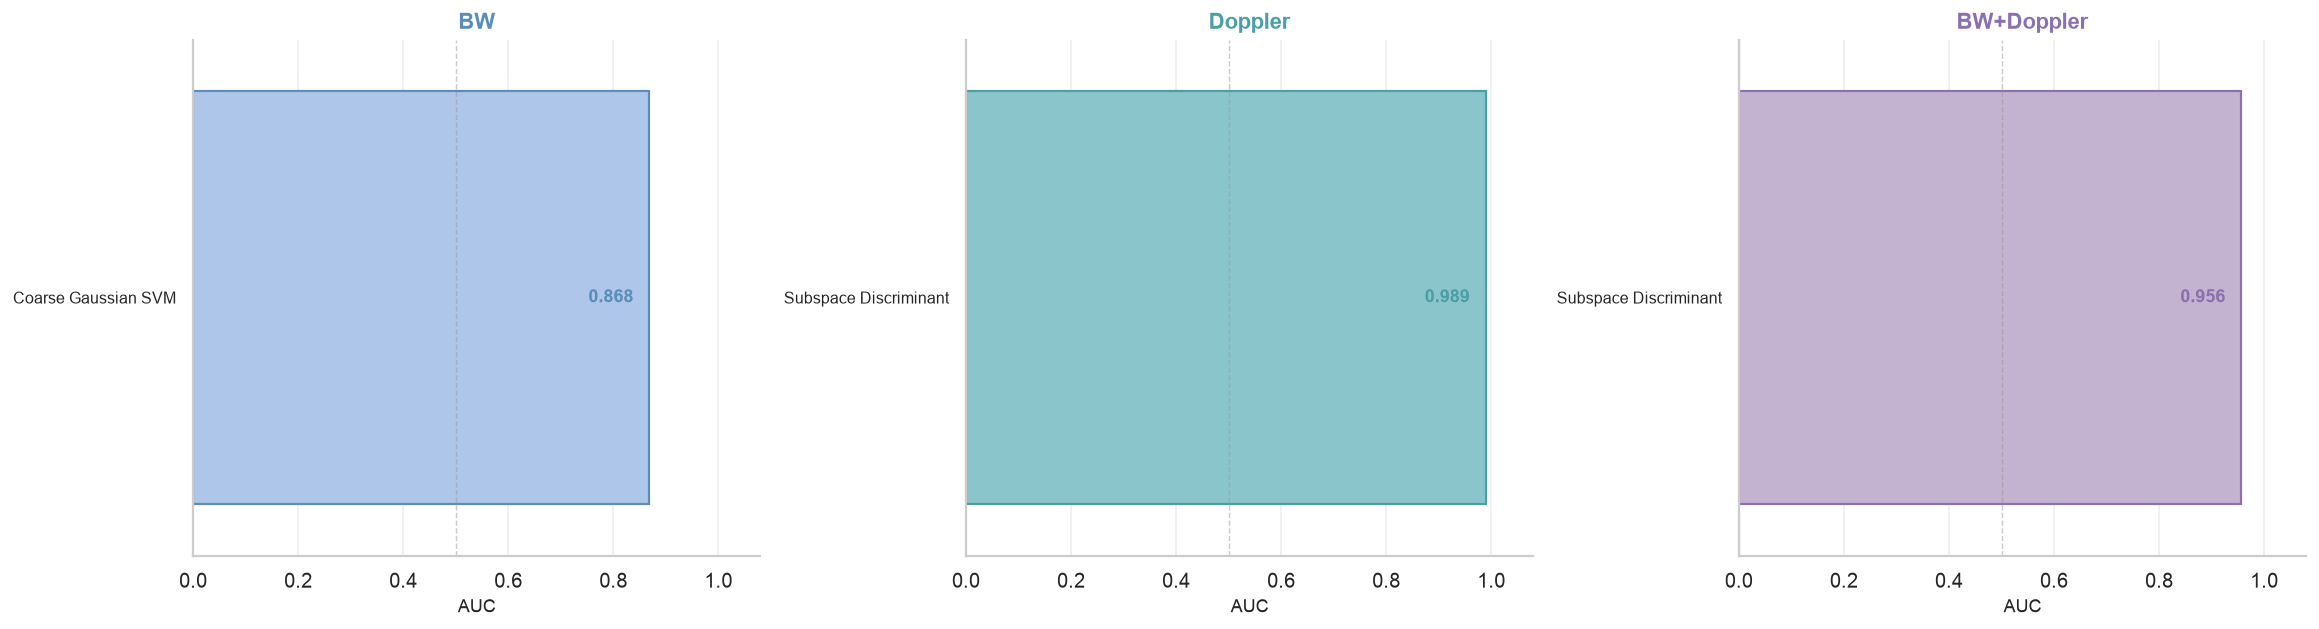

Salvo: /Users/lucasgambim/Documents/TCC-PROJECT/experiments/trilha_a_final/test_auc_barh.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ds_name in zip(axes, DATASETS.keys()):
    sub = df_results[df_results['dataset'] == ds_name].sort_values('test_auc_05')
    color = PASTEL_COLORS[ds_name]
    accent = ACCENT_COLORS[ds_name]

    sns.barplot(x='test_auc_05', y='model', data=sub, ax=ax,
                color=color, edgecolor=accent, linewidth=1.2, orient='h')

    for i, val in enumerate(sub['test_auc_05']):
        ax.text(val - 0.03, i, f'{val:.3f}', va='center', ha='right',
                fontsize=10, fontweight='bold', color=accent)

    ax.set_xlim(0, 1.08)
    ax.axvline(0.5, color='#999999', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('AUC', fontsize=10)
    ax.set_ylabel('')
    ax.set_title(ds_name, fontsize=12, fontweight='bold', color=accent)
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
out_png = os.path.join(OUTPUT_DIR, 'test_auc_barh.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo: {out_png}')

### 6. Visualização — Comparação threshold 0.5 vs Youden (Sensibilidade e Especificidade)

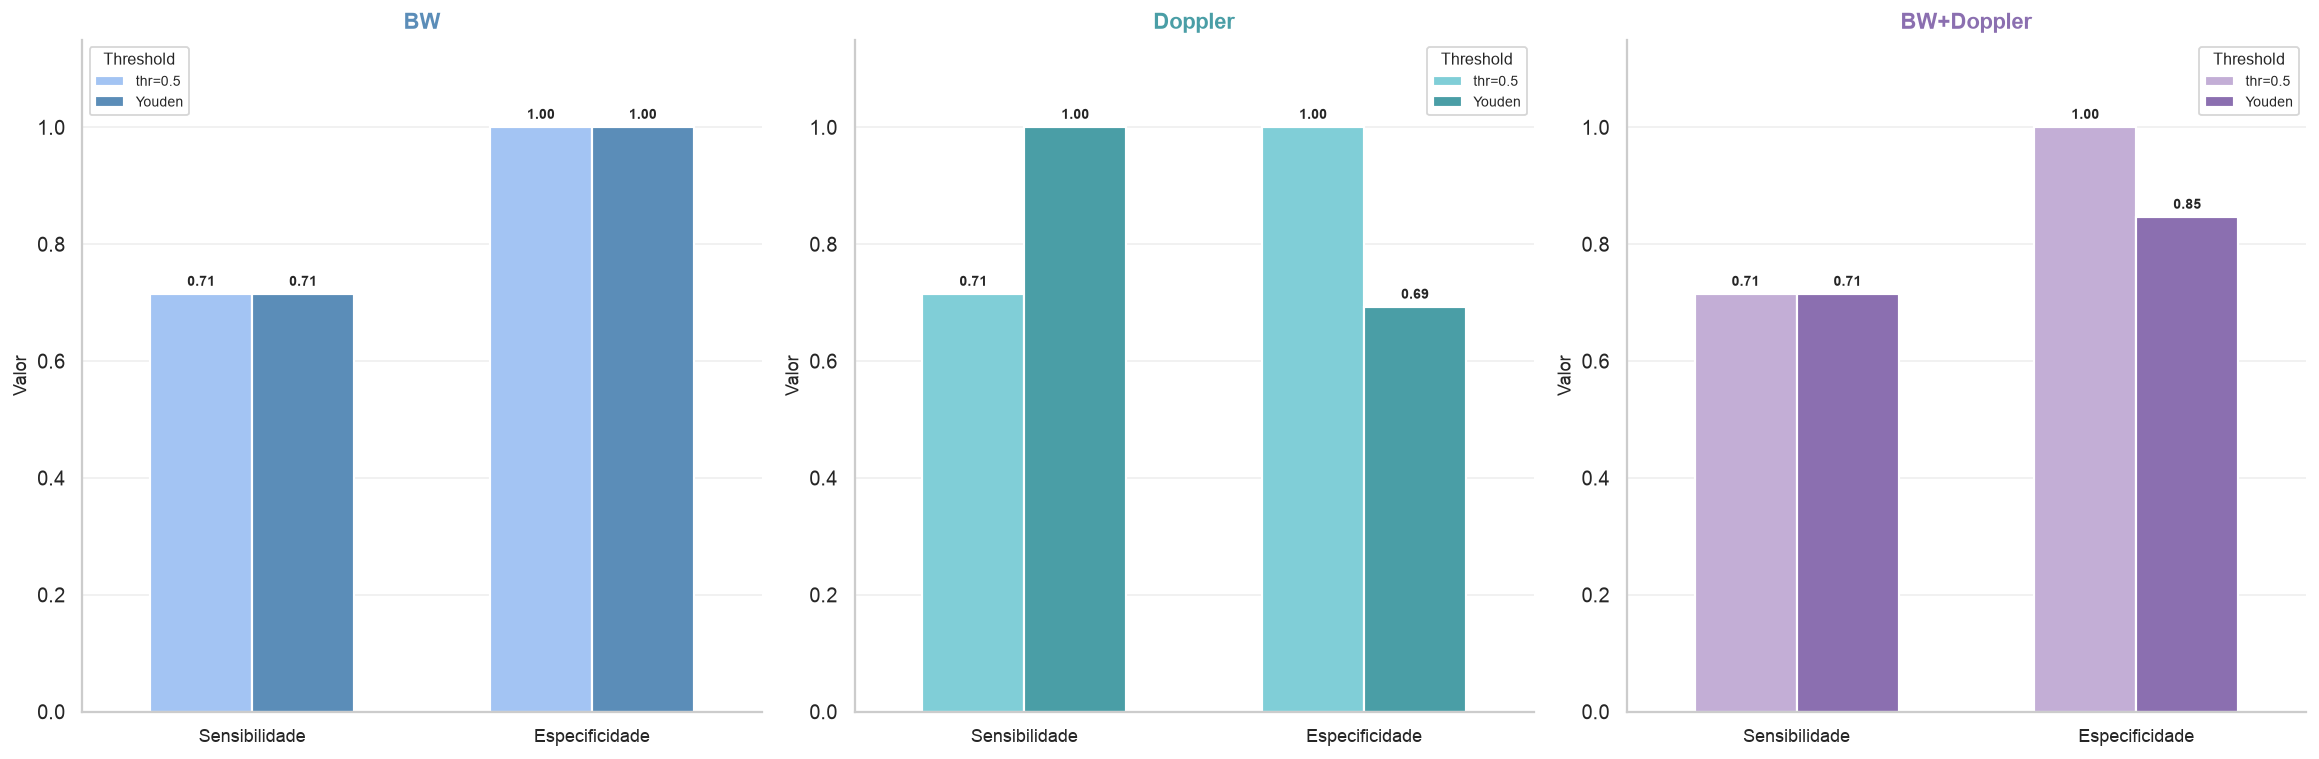

Salvo: /Users/lucasgambim/Documents/TCC-PROJECT/experiments/trilha_a_final/test_sens_spec_comparison.png


In [22]:
rows = []
for ds_name in DATASETS.keys():
    sub = df_results[df_results['dataset'] == ds_name].reset_index(drop=True)
    for _, r in sub.iterrows():
        rows.append({'dataset': ds_name, 'model': r['model'], 'Threshold': 'thr=0.5',
                      'Sensibilidade': r['test_sens_05'], 'Especificidade': r['test_spec_05']})
        rows.append({'dataset': ds_name, 'model': r['model'], 'Threshold': 'Youden',
                      'Sensibilidade': r['test_sens_youden'], 'Especificidade': r['test_spec_youden']})
df_plot = pd.DataFrame(rows)
df_melt = df_plot.melt(id_vars=['dataset', 'model', 'Threshold'],
                       value_vars=['Sensibilidade', 'Especificidade'],
                       var_name='Métrica', value_name='Valor')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, ds_name in zip(axes, DATASETS.keys()):
    sub = df_melt[df_melt['dataset'] == ds_name]
    accent = ACCENT_COLORS[ds_name]
    pastel = PASTEL_COLORS[ds_name]

    palette = {'thr=0.5': pastel, 'Youden': accent}
    sns.barplot(data=sub, x='Métrica', y='Valor', hue='Threshold',
                palette=palette, ax=ax, edgecolor='white', linewidth=1.2,
                saturation=1.0, width=0.6)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=8, fontweight='bold', padding=3)

    ax.set_ylim(0, 1.15)
    ax.set_xlabel('')
    ax.set_ylabel('Valor', fontsize=10)
    ax.set_title(ds_name, fontsize=12, fontweight='bold', color=accent)
    ax.legend(fontsize=8, title='Threshold', title_fontsize=9)
    ax.tick_params(axis='x', labelsize=10)

plt.tight_layout()
out_png = os.path.join(OUTPUT_DIR, 'test_sens_spec_comparison.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo: {out_png}')

### 7. Sumário final

In [23]:
print('=' * 80)
# print(f'TRILHA A — TREINO FINAL  (K={K_FEATURES} features, val={int(VAL_SIZE*100)}%)')
print('=' * 80)

for ds_name in DATASETS:
    sub = df_results[df_results['dataset'] == ds_name]
    print(f'\nDataset: {ds_name}')
    print(f"  {'Modelo':<35} {'AUC':>7} {'Acc':>7} {'Sens':>7} {'Spec':>7} {'F1':>7}  "
          f"{'Thr':>6}  {'AUC_Y':>7} {'Sens_Y':>7} {'Spec_Y':>7}")
    print(f"  {'-'*35} {'-'*7} {'-'*7} {'-'*7} {'-'*7} {'-'*7}  "
          f"{'-'*6}  {'-'*7} {'-'*7} {'-'*7}")
    for _, row in sub.sort_values('test_auc_05', ascending=False).iterrows():
        print(f"  {row['model']:<35} "
              f"{row['test_auc_05']:>7.3f} "
              f"{row['test_acc_05']:>7.3f} "
              f"{row['test_sens_05']:>7.3f} "
              f"{row['test_spec_05']:>7.3f} "
              f"{row['test_f1_05']:>7.3f}  "
              f"{row['threshold_youden']:>6.3f}  "
              f"{row['test_auc_youden']:>7.3f} "
              f"{row['test_sens_youden']:>7.3f} "
              f"{row['test_spec_youden']:>7.3f}")

print(f'\nArquivos salvos em: {OUTPUT_DIR}')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size_kb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) // 1024
    print(f'  {f:<50} {size_kb} KB')


Dataset: BW
  Modelo                                  AUC     Acc    Sens    Spec      F1     Thr    AUC_Y  Sens_Y  Spec_Y
  ----------------------------------- ------- ------- ------- ------- -------  ------  ------- ------- -------
  Coarse Gaussian SVM                   0.868   0.900   0.714   1.000   0.833   0.320    0.868   0.714   1.000

Dataset: Doppler
  Modelo                                  AUC     Acc    Sens    Spec      F1     Thr    AUC_Y  Sens_Y  Spec_Y
  ----------------------------------- ------- ------- ------- ------- -------  ------  ------- ------- -------
  Subspace Discriminant                 0.989   0.900   0.714   1.000   0.833   0.187    0.989   1.000   0.692

Dataset: BW+Doppler
  Modelo                                  AUC     Acc    Sens    Spec      F1     Thr    AUC_Y  Sens_Y  Spec_Y
  ----------------------------------- ------- ------- ------- ------- -------  ------  ------- ------- -------
  Subspace Discriminant                 0.956   0.900   0.71

### 8. Probabilidade Predita no Teste por Dataset

In [ ]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

benign_color = '#A3C4F3'
malign_color = '#C3AED6'

for ax, ds_name in zip(axes, DATASETS.keys()):
    row_top = df_results[df_results['dataset'] == ds_name].iloc[0]
    model_name = row_top['model']
    thr_youden = row_top['threshold_youden']
    accent = ACCENT_COLORS[ds_name]
    is_proba = test_is_proba[ds_name]

    prob_test = test_probs[ds_name]
    y_te = splits[ds_name]['y_test']

    # Zona de incerteza: região onde os dois thresholds divergem na classificação
    ax.axhspan(min(0.5, thr_youden), max(0.5, thr_youden),
               color=accent, alpha=0.18, zorder=1)

    colors = [malign_color if y == 1 else benign_color for y in y_te]
    ax.scatter(range(len(prob_test)), prob_test, c=colors,
               alpha=0.85, edgecolors='#555555', linewidths=0.6, s=70, zorder=3)

    if is_proba:
        ax.axhline(y=0.5, color='#999999', linestyle='--', linewidth=1.0, alpha=0.6)
        ax.set_ylim(-0.05, 1.05)
        ax.set_ylabel('Probabilidade predita (maligno)', fontsize=9)
    else:
        ax.axhline(y=0.0, color='#999999', linestyle='--', linewidth=1.0, alpha=0.6)
        ax.set_ylabel('Score de decisão (maligno)', fontsize=9)

    ax.axhline(y=thr_youden, color=accent, linestyle=':', linewidth=1.5)
    ax.set_xlabel('Amostra (teste)', fontsize=9)
    ax.set_title(f'{ds_name} — {model_name}', fontsize=11, fontweight='bold', color=accent)

    legend_elements = [
        Line2D([0], [0], color='#999999', linestyle='--', label='thr=0.5'),
        Line2D([0], [0], color=accent, linestyle=':', linewidth=1.5, label=f'Youden={thr_youden:.2f}'),
        Line2D([0], [0], color=accent, linewidth=8, alpha=0.25, label='Zona de incerteza'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=benign_color,
               markersize=8, markeredgecolor='#555', label='Benigno'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=malign_color,
               markersize=8, markeredgecolor='#555', label='Maligno'),
    ]
    ax.legend(handles=legend_elements, fontsize=7, loc='upper right')

plt.tight_layout()
out_png = os.path.join(OUTPUT_DIR, 'test_predicted_probs.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo: {out_png}')

### 9. Matrizes de Confusão no Teste (threshold=0.5 e Youden)

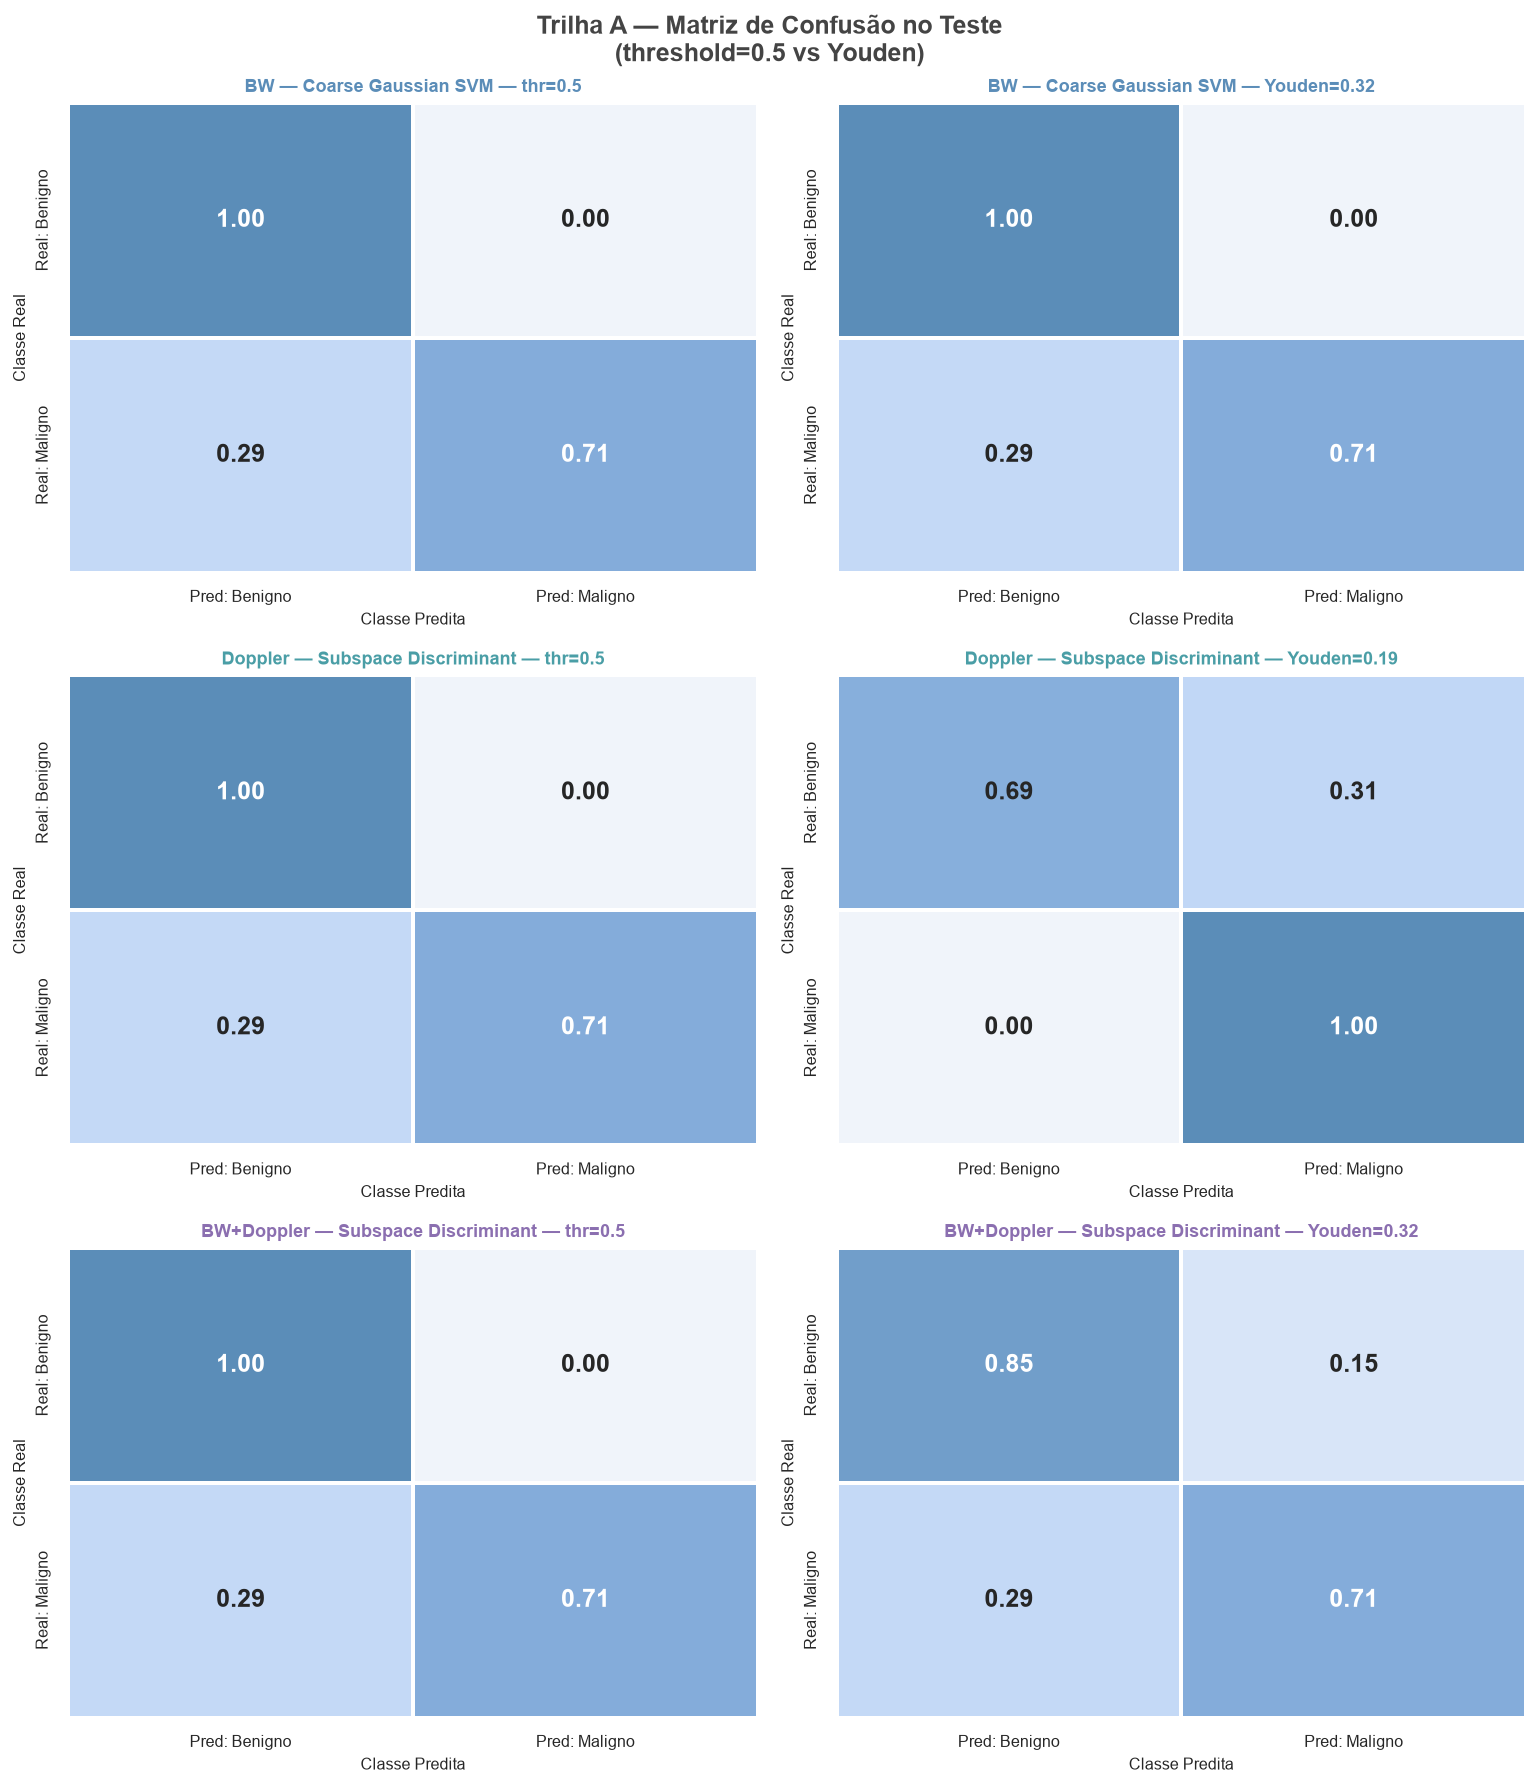

Salvo: /Users/lucasgambim/Documents/TCC-PROJECT/experiments/trilha_a_final/test_confusion_matrices.png


In [25]:
from typing import Any, Literal
from sklearn.metrics import confusion_matrix as sk_confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

pastel_cmap = LinearSegmentedColormap.from_list('pastel_blues',
    ['#F0F4FA', '#A3C4F3', '#5B8DB8'], N=256)

fig, axes = plt.subplots(3, 2, figsize=(12, 14))
fig.suptitle('Trilha A — Matriz de Confusão no Teste\n(threshold=0.5 vs Youden)',
             fontsize=14, fontweight='bold', color='#444444')

for row_idx, ds_name in enumerate[Any](DATASETS.keys()):
    row_top = df_results[df_results['dataset'] == ds_name].iloc[0]
    model_name = row_top['model']
    thr_youden = row_top['threshold_youden']
    accent = ACCENT_COLORS[ds_name]

    prob_test = test_probs[ds_name]
    y_te = splits[ds_name]['y_test']

    for col_idx, (thr, thr_label) in enumerate[tuple[float, Literal['thr=0.5']] | tuple[Any, str]]([(0.5, 'thr=0.5'), (thr_youden, f'Youden={thr_youden:.2f}')]):
        y_pred = (prob_test >= thr).astype(int)
        cm = sk_confusion_matrix(y_te, y_pred, normalize="true")
        labels = ['Benigno', 'Maligno']
        cm_df = pd.DataFrame(
            cm,
            index=[f'Real: {l}' for l in labels],
            columns=[f'Pred: {l}' for l in labels]
        )

        ax = axes[row_idx][col_idx]
        sns.heatmap(
            cm_df, annot=True, fmt='.2f', cmap=pastel_cmap, cbar=False,
            annot_kws={'size': 14, 'fontweight': 'bold'},
            vmin=0, vmax=1, linewidths=2, linecolor='white',
            ax=ax
        )

        ax.set_title(f'{ds_name} — {model_name} — {thr_label}',
                     fontsize=10, color=accent, fontweight='bold')
        ax.set_xlabel('Classe Predita', fontsize=9)
        ax.set_ylabel('Classe Real', fontsize=9)
        ax.tick_params(labelsize=9)

plt.tight_layout()
out_png = os.path.join(OUTPUT_DIR, 'test_confusion_matrices.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo: {out_png}')

### 10. Curva ROC no Teste por Dataset

Curvas ROC dos modelos finais no teste, com ponto de destaque para o threshold de Youden.

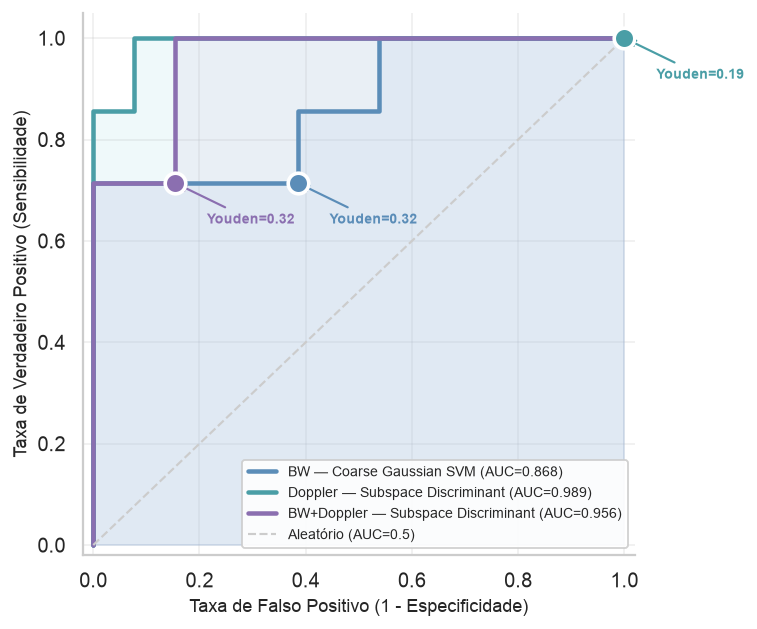

Salvo: /Users/lucasgambim/Documents/TCC-PROJECT/experiments/trilha_a_final/test_roc_curves.png
ROC data salvo para plot combinado


In [26]:
import pickle
from sklearn.metrics import roc_curve as sk_roc_curve, auc as sk_auc

roc_data = {}
fig, ax = plt.subplots(figsize=(6, 5))

for ds_name in DATASETS:
    y_te = splits[ds_name]['y_test']
    prob_test = test_probs[ds_name]
    row_top = df_results[df_results['dataset'] == ds_name].iloc[0]
    thr_youden = row_top['threshold_youden']
    accent = ACCENT_COLORS[ds_name]
    pastel = PASTEL_COLORS[ds_name]

    fpr, tpr, thresholds = sk_roc_curve(y_te, prob_test)
    roc_auc = sk_auc(fpr, tpr)

    idx_youden = np.argmin(np.abs(thresholds - thr_youden))
    roc_data[ds_name] = {
        'fpr': fpr, 'tpr': tpr, 'auc': roc_auc,
        'model': row_top['model'], 'thr_youden': thr_youden,
        'fpr_youden': float(fpr[idx_youden]),
        'tpr_youden': float(tpr[idx_youden]),
    }

    ax.plot(fpr, tpr, color=accent, lw=2.5,
            label=f"{ds_name} — {row_top['model']} (AUC={roc_auc:.3f})")
    ax.fill_between(fpr, tpr, alpha=0.12, color=pastel)
    ax.scatter(fpr[idx_youden], tpr[idx_youden], color=accent, s=130,
               zorder=5, edgecolors='white', linewidths=2, marker='o')
    ax.annotate(f'Youden={thr_youden:.2f}',
                xy=(fpr[idx_youden], tpr[idx_youden]),
                xytext=(fpr[idx_youden] + 0.06, tpr[idx_youden] - 0.08),
                fontsize=8, color=accent, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=accent, lw=1.2))

ax.plot([0, 1], [0, 1], color='#CCCCCC', linestyle='--', lw=1.2, label='Aleatório (AUC=0.5)')
ax.set_xlabel('Taxa de Falso Positivo (1 - Especificidade)', fontsize=10)
ax.set_ylabel('Taxa de Verdadeiro Positivo (Sensibilidade)', fontsize=10)
ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)

plt.tight_layout()
out_png = os.path.join(OUTPUT_DIR, 'test_roc_curves.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()

with open(os.path.join(OUTPUT_DIR, 'roc_data.pkl'), 'wb') as f:
    pickle.dump(roc_data, f)
print(f'Salvo: {out_png}')
print(f'ROC data salvo para plot combinado')